# import

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import my_module as my


# Tests & Models
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.model_selection import cross_val_score
from statsmodels.tsa.ar_model import AutoReg, AutoRegResults

from sklearn.metrics import mean_squared_error, accuracy_score


from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Misc
from sklearn.model_selection import TimeSeriesSplit
from itertools import product

***
# 0. Leitura e processamento inicial de dados

In [6]:
df = pd.read_csv('data/dados.csv', index_col='Data')
df.head()

,Último,Abertura,Máxima,Mínima,Vol.,Var%
Data,,,,,,
30.06.2025,138.855,136.865,139.103,136.430,"7,68M","1,45%"
27.06.2025,136.866,137.113,137.209,136.469,"6,24B","-0,18%"
26.06.2025,137.114,135.767,137.353,135.756,"8,02B","0,99%"
25.06.2025,135.767,137.163,137.163,135.565,"7,71B","-1,02%"
24.06.2025,137.165,136.552,138.156,136.254,"8,08B","0,45%"


In [7]:
col_dict = my.format_columns(df)
df.head()

,ultimo,abertura,maxima,minima,vol,var
Data,,,,,,
30.06.2025,138.855,136.865,139.103,136.430,"7,68M","1,45%"
27.06.2025,136.866,137.113,137.209,136.469,"6,24B","-0,18%"
26.06.2025,137.114,135.767,137.353,135.756,"8,02B","0,99%"
25.06.2025,135.767,137.163,137.163,135.565,"7,71B","-1,02%"
24.06.2025,137.165,136.552,138.156,136.254,"8,08B","0,45%"


In [8]:
df.dtypes

ultimo      float64
abertura    float64
maxima      float64
minima      float64
vol          object
var          object
dtype: object

## Tratamento e formatação de valores

In [9]:
# Formatacao e nomeacao do index
df.index = pd.to_datetime(df.index, dayfirst=True)
df.index = df.index.rename('data')
col_dict ['data'] = 'Data'
df.head()

,ultimo,abertura,maxima,minima,vol,var
data,,,,,,
2025-06-30,138.855,136.865,139.103,136.430,"7,68M","1,45%"
2025-06-27,136.866,137.113,137.209,136.469,"6,24B","-0,18%"
2025-06-26,137.114,135.767,137.353,135.756,"8,02B","0,99%"
2025-06-25,135.767,137.163,137.163,135.565,"7,71B","-1,02%"
2025-06-24,137.165,136.552,138.156,136.254,"8,08B","0,45%"


In [10]:
# Tornando 'var' em numero
df['var'] = df['var'].replace('%','',regex=True).replace(',','.',regex=True)
df['var'] = df['var'].astype(float)
df.head()

,ultimo,abertura,maxima,minima,vol,var
data,,,,,,
2025-06-30,138.855,136.865,139.103,136.430,"7,68M",1.45
2025-06-27,136.866,137.113,137.209,136.469,"6,24B",-0.18
2025-06-26,137.114,135.767,137.353,135.756,"8,02B",0.99
2025-06-25,135.767,137.163,137.163,135.565,"7,71B",-1.02
2025-06-24,137.165,136.552,138.156,136.254,"8,08B",0.45


In [11]:
# Ordenando nosso index
df = df.sort_index()
df.head()

,ultimo,abertura,maxima,minima,vol,var
data,,,,,,
2010-01-29,65.402,65.591,66.576,65.140,"1,82M",-0.28
2010-02-01,66.572,65.402,66.763,65.362,"1,49M",1.79
2010-02-02,67.163,66.589,67.321,66.539,"1,59M",0.89
2010-02-03,67.109,67.163,67.347,66.774,"1,76M",-0.08
2010-02-04,63.934,67.100,67.100,63.750,"2,26M",-4.73


In [12]:
# Retirando colunas irrelevantes
df = df.drop(['maxima','minima', 'abertura', 'ultimo', 'vol'], axis=1)
df.head()

,var
data,
2010-01-29,-0.28
2010-02-01,1.79
2010-02-02,0.89
2010-02-03,-0.08
2010-02-04,-4.73


In [13]:
df = df.asfreq('d')

filled_days = df.isna()

filled_days

,var
data,
2010-01-29,False
2010-01-30,True
2010-01-31,True
2010-02-01,False
2010-02-02,False
...,...
2025-06-26,False
2025-06-27,False
2025-06-28,True


In [14]:
df = df.fillna('0')
df.head(10)

,var
data,
2010-01-29,-0.28
2010-01-30,0
2010-01-31,0
2010-02-01,1.79
2010-02-02,0.89
2010-02-03,-0.08
2010-02-04,-4.73
2010-02-05,-1.83
2010-02-06,0


In [15]:
df['var'] = df['var'].astype(float)
df.head()

,var
data,
2010-01-29,-0.28
2010-01-30,0.00
2010-01-31,0.00
2010-02-01,1.79
2010-02-02,0.89


In [16]:
df['alta'] = False
df.loc[df['var'] > 0, 'alta'] = True
df

,var,alta
data,,
2010-01-29,-0.28,False
2010-01-30,0.00,False
2010-01-31,0.00,False
2010-02-01,1.79,True
2010-02-02,0.89,True
...,...,...
2025-06-26,0.99,True
2025-06-27,-0.18,False
2025-06-28,0.00,False


# 1. Análise inicial

In [17]:
sns.set_style('darkgrid')

In [18]:
target_col = ['var']

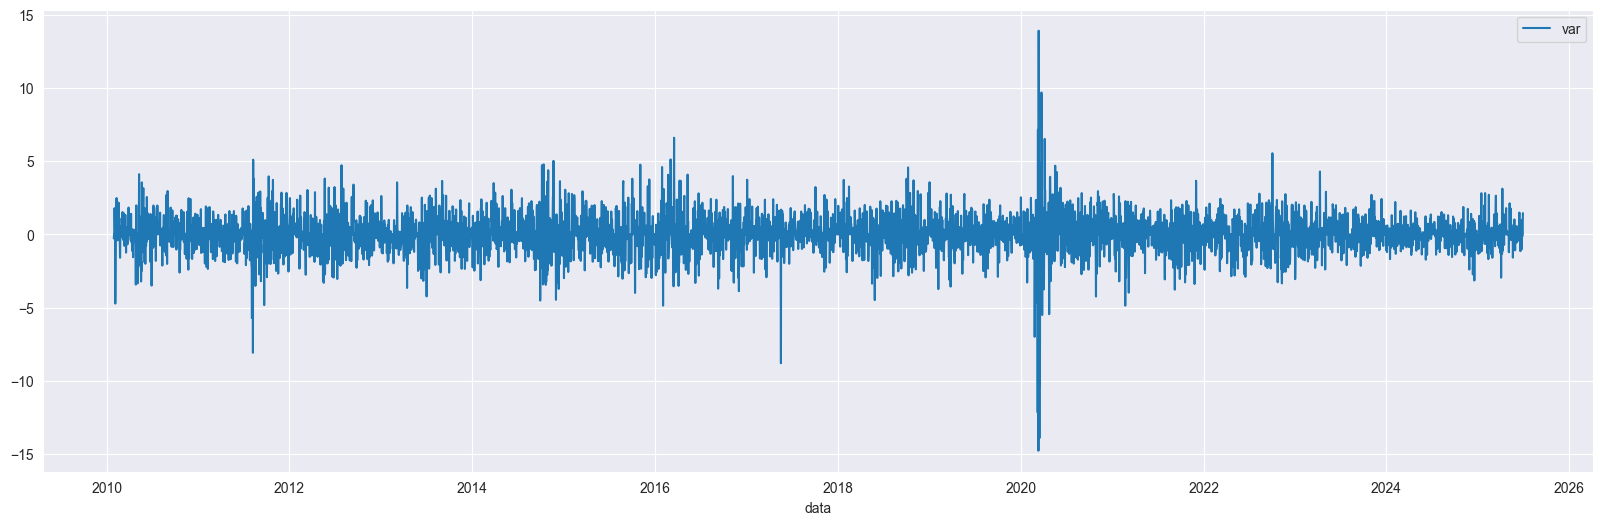

In [19]:
fig = plt.figure(figsize=(20,6))
sns.lineplot(
    df[target_col]
);

## Dados originais

### seasonal_decompose
Apenas do ano de 2023

#### import

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose, MSTL

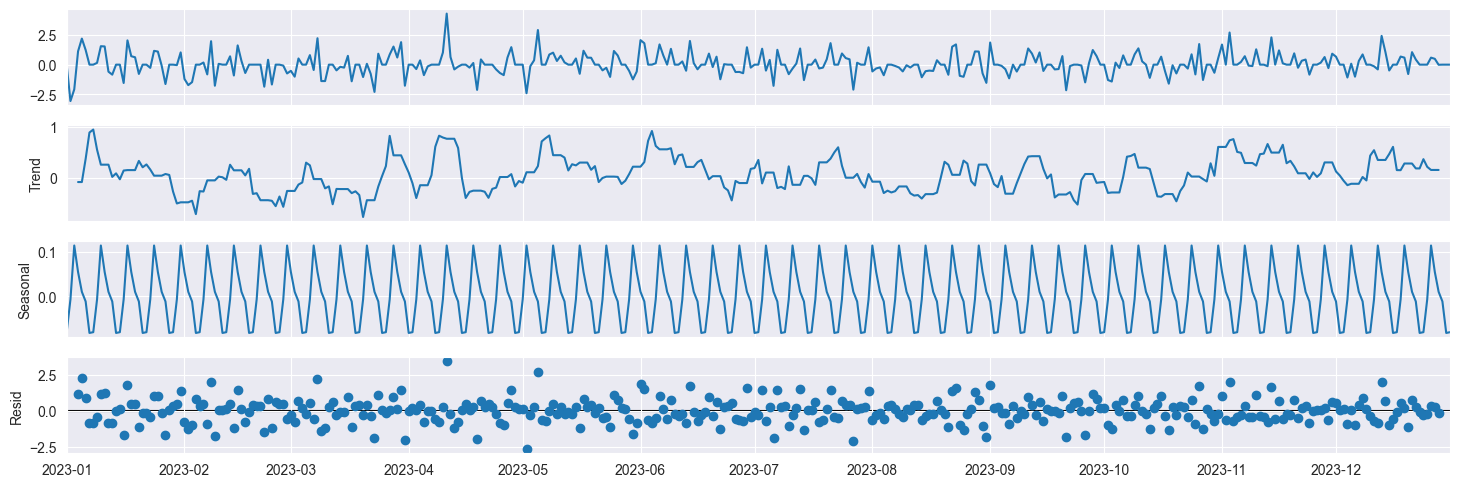

In [21]:
year = 2023
mask = ((df.index > f'{year-1}-12-31') & (df.index < f'{year+1}-01-01'))
fig = seasonal_decompose(
    df[target_col].loc[mask],
    model = 'additive',
    period = 7
).plot();

fig.set_size_inches(16, 5)

In [22]:
results = []
for p in range(2, 31*4):
    result = seasonal_decompose(
        df[target_col].loc[mask],
        model = 'additive',
        period = p
    )

    results.append((p, result, abs(result.resid.mean())))

results.sort(key = lambda x: x[2])
results[:10]

[(14,
  np.float64(1.1538461538444136e-05)),
 (21,
  np.float64(7.352941176470787e-05)),
 (26,
  np.float64(0.0002532674426165468)),
 (18,
  np.float64(0.0003372725795971572)),
 (15,
  np.float64(0.0004332528180354233)),
 (30,
  np.float64(0.00047521043771043924)),
 (19,
  np.float64(0.00048508852926406194)),
 (111,
  np.float64(0.000495766036306596)),
 (17,
  np.float64(0.0006646070192783139)),
 (59,
  np.float64(0.0006665709087427243))]

0.38294300474186915 0.0011876652568164128


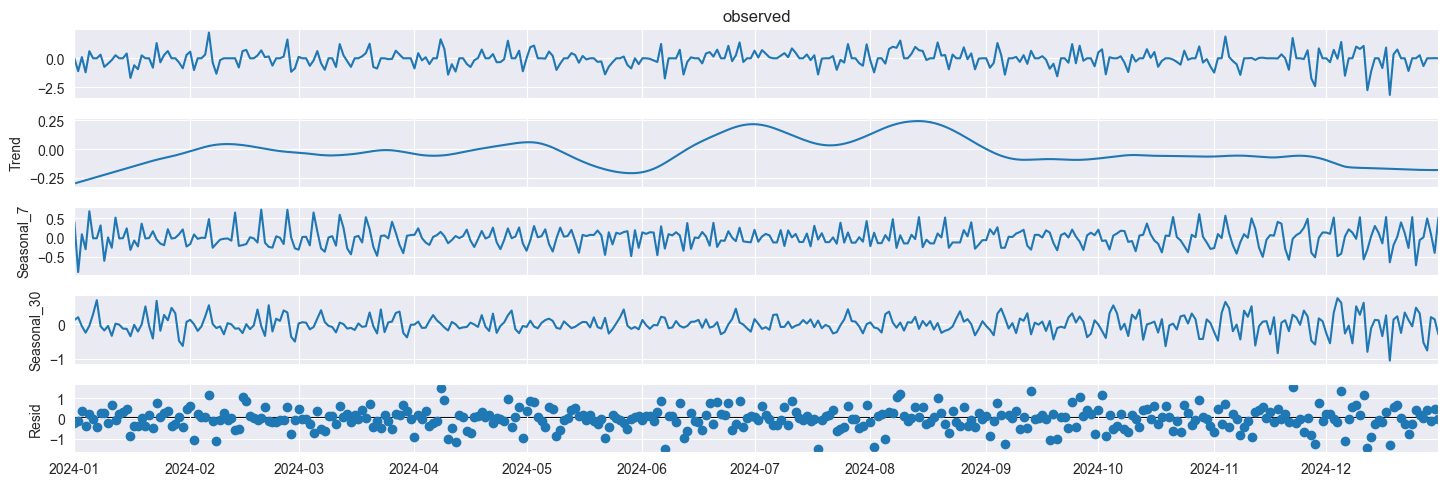

In [23]:
year = 2024
mask = ((df.index > f'{year-1}-12-31') & (df.index < f'{year+1}-01-01'))

mstl = MSTL(
    df[target_col].loc[mask],
    periods = [7, 30])
mstl_fit = mstl.fit()

fig = mstl_fit.plot()

fig.set_size_inches(16, 5)

print(mstl_fit.resid.abs().mean(), mstl_fit.resid.mean())

***
# 2. Encontrando um modelo

In [24]:
SEED = 154

## Separação de dados

### Separação simples

In [25]:
prediction_n = 30
y_train = df.iloc[:-prediction_n][target_col]
y_test = df.iloc[-prediction_n:][target_col]

print(f'Train\t{len(y_train)}\nTest\t{len(y_test)}')

Train	5602
Test	30


### Separação K-Fold

In [26]:
n_folds = 3
folds = {}

splitter = TimeSeriesSplit(
    n_splits = n_folds
)

for i, (train_index, test_index) in enumerate(splitter.split(df)):
    print(f"Fold {i}:")

    print(f"  Train: index={train_index} ({len(train_index)})")

    print(f"  Test:  index={test_index} ({len(test_index)})")

    folds[i] = (train_index, test_index)


Fold 0:
  Train: index=[   0    1    2 ... 1405 1406 1407] (1408)
  Test:  index=[1408 1409 1410 ... 2813 2814 2815] (1408)
Fold 1:
  Train: index=[   0    1    2 ... 2813 2814 2815] (2816)
  Test:  index=[2816 2817 2818 ... 4221 4222 4223] (1408)
Fold 2:
  Train: index=[   0    1    2 ... 4221 4222 4223] (4224)
  Test:  index=[4224 4225 4226 ... 5629 5630 5631] (1408)


## Modelo baseline

In [27]:
model_predictions = {}

In [28]:
current_model = 'arima_baseline'

model_arima_baseline = ARIMA(
    y_train[target_col],
    order = (1, 1, 0)
)

y_pred = model_arima_baseline.fit().forecast(steps = len(y_test))

model_predictions[current_model] = [model_arima_baseline, y_pred]


In [29]:
def plot_prediction(y_train, y_pred, y_test, model_name : str = ''):
    fig = plt.figure(figsize = (16, 6))
    fig.suptitle(model_name,fontsize=20)

    ax = plt.subplot()

    ax.plot(
        y_train,
        label = 'Train',
    )

    ax.plot(
        y_pred,
        label = 'Predicted',
        color = 'red'
    )

    ax.plot(
        y_test,
        label = 'Expected',
        color = 'green',
        alpha = 0.5
    )
    plt.legend()

    print(f'MSE\t {mean_squared_error(y_test, y_pred)}')

MSE	 0.5197836628170326


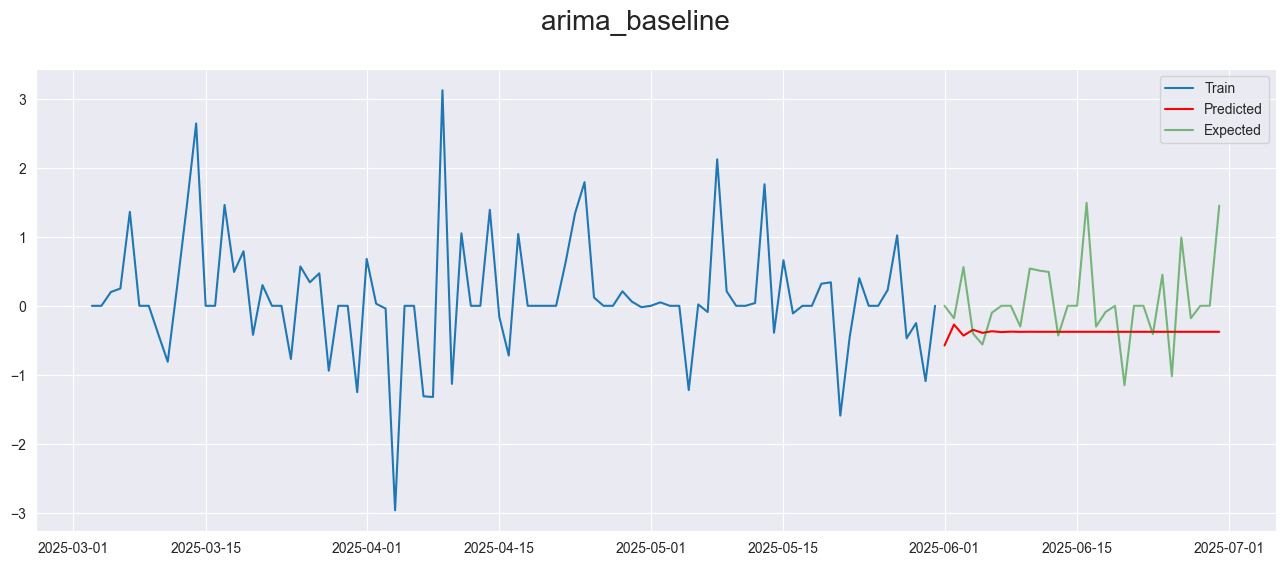

In [30]:
plot_prediction(
    y_train = y_train[-prediction_n - prediction_n*2:],
    y_pred = model_predictions[current_model][1],
    y_test = y_test,
    model_name = current_model
)

#### Statistics
AIC = 15578.645

MSE = 0.8532

## StatsForecastMSTL

### import

In [31]:
from sktime.forecasting.statsforecast import StatsForecastMSTL

In [32]:
current_model = 'statsforecastmstl(7, 31, 365)'

model_mstl = StatsForecastMSTL(
    season_length = [7, 31, 365]
)

model_mstl_fit = model_mstl.fit(y = y_train)

y_pred = model_mstl.predict(fh = [x for x in range(1, prediction_n+1)])

model_predictions[current_model] = [model_mstl, y_pred]

d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\fs\__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MSE	 0.5163474824244987


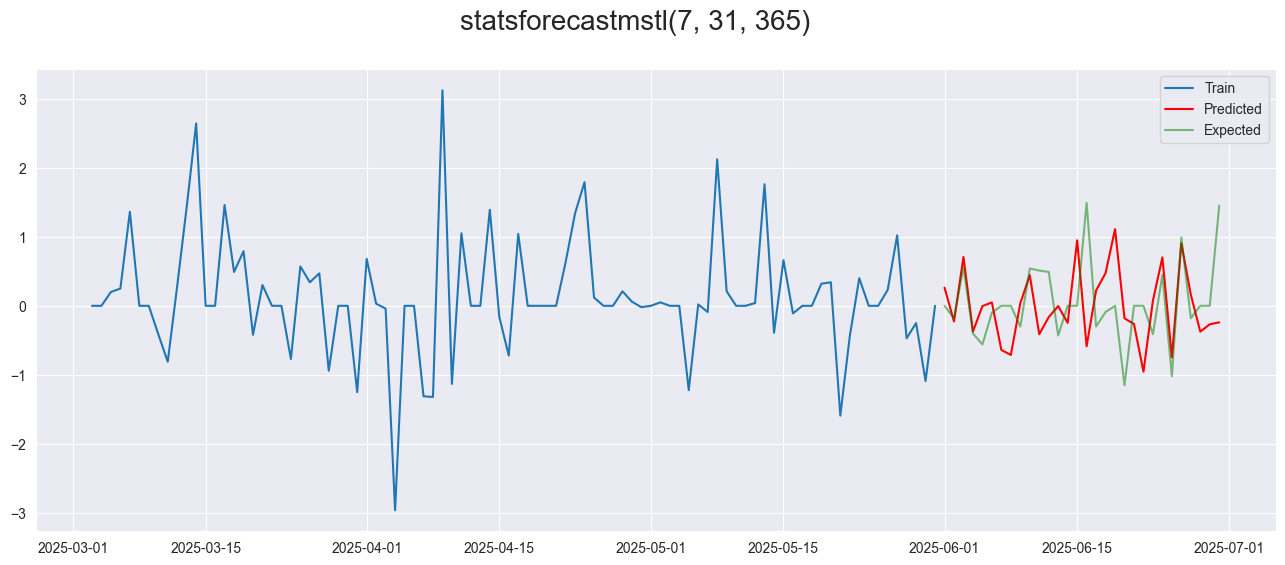

In [33]:
plot_prediction(
    y_train = y_train[-prediction_n - prediction_n*2:],
    y_pred = model_predictions[current_model][1],
    y_test = y_test,
    model_name = current_model
)

### Avaliando 

In [34]:
y_pred = model_predictions[current_model][1]

In [35]:
filled_days = df.loc[filled_days['var'] == True].index

In [36]:
y_test['increase'] = False

mask = y_test['var'] > 0
y_test.loc[mask, 'increase'] = True

y_test.head()

,var,increase
data,,
2025-06-01,0.00,False
2025-06-02,-0.18,False
2025-06-03,0.56,True
2025-06-04,-0.40,False
2025-06-05,-0.56,False


In [37]:
y_pred['increase'] = False
mask = y_pred['var'] > 0
y_pred.loc[mask, 'increase'] = True
y_pred.head()

,var,increase
2025-06-01,0.263021,True
2025-06-02,-0.226037,False
2025-06-03,0.707015,True
2025-06-04,-0.372561,False
2025-06-05,-0.004071,False


In [38]:
accuracy_score(
    y_test['increase'],
    y_pred['increase']
)

0.5666666666666667

## ARIMA

In [39]:
def grid_arima(df : pd.DataFrame, pmin : int, pmax : int, dmin : int, dmax : int, qmin : int, qmax : int):
    p = range(pmin, pmax+1)
    d = range(dmin, dmax+1)
    q = range(qmin, qmax+1)

    pqd = list(product(p, d, q))

    aics = []

    for order in pqd:
        # print(f'Testing {order}')
        try:
            model = ARIMA(
                df,
                order = order
            ).fit()
            aics.append((order, model.aic))
        except:
            print(f'Failed {order}, moving on')
            continue
    
    # ordenando por menor AIC
    aics.sort(key = lambda x: x[1])

    return aics

### ACF, PACF

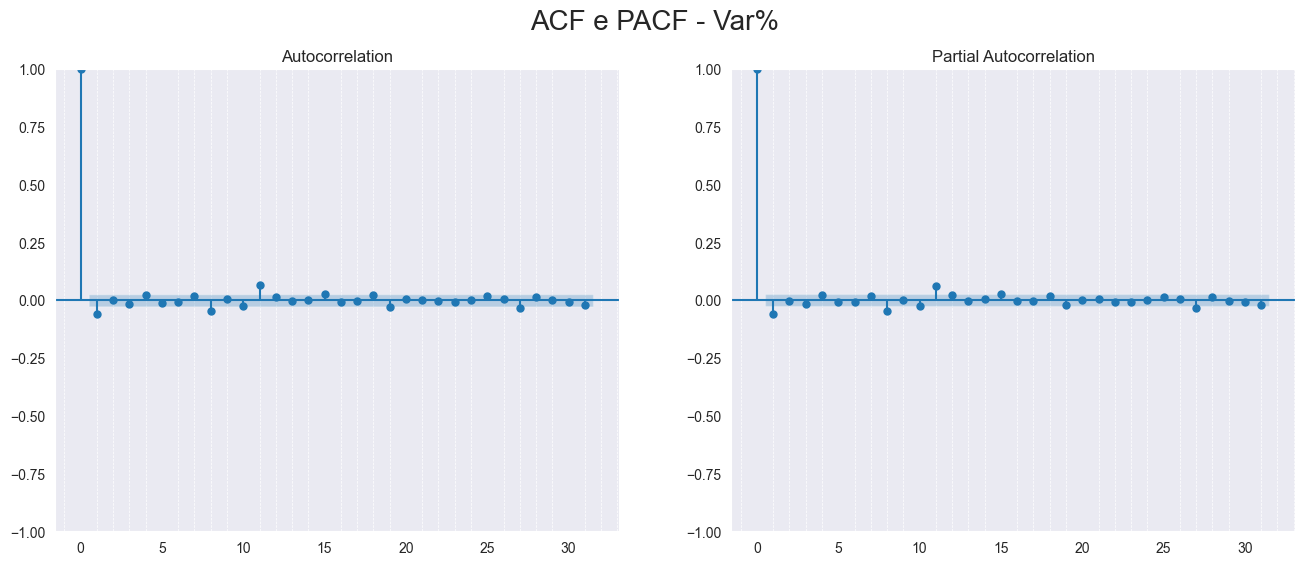

In [43]:
shift = 31*1
lags = 31

fig, axs = plt.subplots(
    nrows = 1,
    ncols = 2,
    figsize = (16, 6)
)

fig.suptitle(
    f'ACF e PACF - {col_dict[target_col[0]]}',
    fontsize = 20
)

ax = axs[0]
plot_acf(
    df[target_col],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

ax = axs[1]
plot_pacf(
    df[target_col],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

plt.show()


### grid

In [44]:
# grid_arima_results = grid_arima(
#     df = y_train,
#     pmin = 8,
#     pmax = 15,
#     dmin = 0,
#     dmax = 0,
#     qmin = 2,
#     qmax = 5
# )

# grid_arima_results

## LSTM

## RandomForest

In [45]:
df_forest = df.copy()

for i in [1, 2, 7, 30]:
    df_forest[f'shift{i}'] = df['var'].shift(i)

df_forest = df_forest[30:]

df_forest

,var,alta,shift1,shift2,shift7,shift30
data,,,,,,
2010-02-28,0.00,False,0.00,0.58,0.00,-0.28
2010-03-01,1.09,True,0.00,0.00,-0.61,0.00
2010-03-02,0.82,True,1.09,0.00,-1.60,0.00
2010-03-03,-0.20,False,0.82,1.09,-0.47,1.79
2010-03-04,0.26,True,-0.20,0.82,0.50,0.89
...,...,...,...,...,...,...
2025-06-26,0.99,True,-1.02,0.45,0.00,1.02
2025-06-27,-0.18,False,0.99,-1.02,-1.15,-0.47
2025-06-28,0.00,False,-0.18,0.99,0.00,-0.25


In [46]:
df_forest['alta'] = False
df_forest.loc[df['var'] > 0, 'alta'] = True
df_forest

,var,alta,shift1,shift2,shift7,shift30
data,,,,,,
2010-02-28,0.00,False,0.00,0.58,0.00,-0.28
2010-03-01,1.09,True,0.00,0.00,-0.61,0.00
2010-03-02,0.82,True,1.09,0.00,-1.60,0.00
2010-03-03,-0.20,False,0.82,1.09,-0.47,1.79
2010-03-04,0.26,True,-0.20,0.82,0.50,0.89
...,...,...,...,...,...,...
2025-06-26,0.99,True,-1.02,0.45,0.00,1.02
2025-06-27,-0.18,False,0.99,-1.02,-1.15,-0.47
2025-06-28,0.00,False,-0.18,0.99,0.00,-0.25


### import

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

In [48]:
prediction_n = 30

y_train = df_forest.iloc[:-prediction_n]['alta']
y_test = df_forest.iloc[-prediction_n:]['alta']

x_train = df_forest.iloc[:-prediction_n][['shift1', 'shift2', 'shift7', 'shift30']]
x_test = df_forest.iloc[-prediction_n:][['shift1', 'shift2', 'shift7', 'shift30']]

print(f'Train\t{len(y_train)}\nTest\t{len(y_test)}')

Train	5572
Test	30


<Axes: >

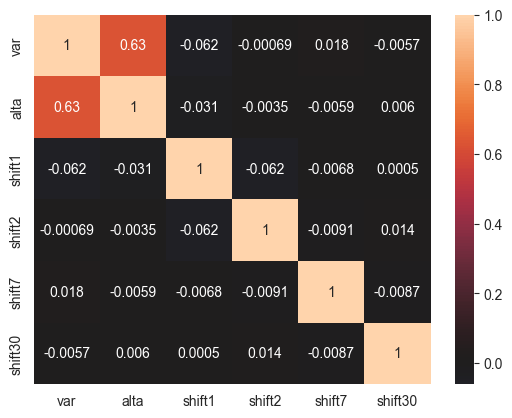

In [49]:
sns.heatmap(
    df_forest.corr(),
    annot = True,
    center = 0
)

In [50]:
current_model = 'rfc(100, 20)'
rfc = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 20, # 20
    random_state = SEED)

rfc_fit = rfc.fit(x_train, y_train)

In [51]:
y_pred = rfc_fit.predict(x_test)
y_pred

array([False, False,  True, False, False,  True, False, False, False,
        True,  True,  True,  True, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False])

In [52]:
accuracy_score(y_test, y_pred)

0.7666666666666667

In [53]:
model_predictions[current_model] = [rfc, y_pred]

>1, train: 0.652, test: 0.733
>2, train: 0.653, test: 0.733
>3, train: 0.661, test: 0.733
>4, train: 0.677, test: 0.800
>5, train: 0.701, test: 0.767
>6, train: 0.739, test: 0.700
>7, train: 0.775, test: 0.700
>8, train: 0.806, test: 0.733
>9, train: 0.835, test: 0.700
>10, train: 0.862, test: 0.667
>11, train: 0.883, test: 0.733
>12, train: 0.901, test: 0.700
>13, train: 0.915, test: 0.767
>14, train: 0.925, test: 0.700
>15, train: 0.934, test: 0.733
>16, train: 0.937, test: 0.733
>17, train: 0.943, test: 0.667
>18, train: 0.950, test: 0.733
>19, train: 0.954, test: 0.767
>20, train: 0.955, test: 0.733


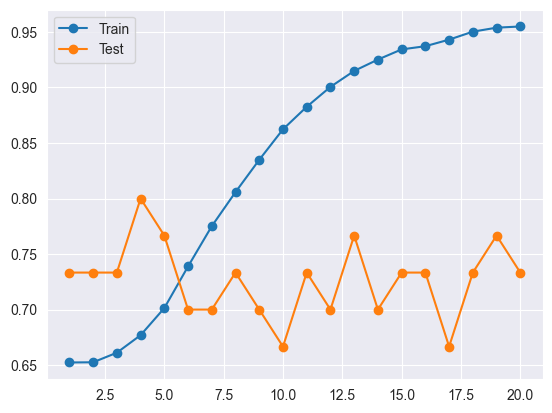

In [54]:
# define lists to collect scores
train_scores, test_scores = list(), list()

# define the tree depths to evaluate
values = [i for i in range(1, 21)]

# evaluate a decision tree for each depth
for i in values:
	# configure the model
	model = RandomForestClassifier(
		n_estimators = 50,
		max_depth = i,
		random_state = SEED
		)
	# fit model on the training dataset
	model.fit(x_train, y_train)
	
	# evaluate on the train dataset
	y_pred = model.predict(x_train)
	train_acc = accuracy_score(y_train, y_pred)
	train_scores.append(train_acc)
	
	# evaluate on the test dataset
	y_pred = model.predict(x_test)
	test_acc = accuracy_score(y_test, y_pred)
	test_scores.append(test_acc)
	
    # summarize progress
	print('>%d, train: %.3f, test: %.3f' % (i, train_acc, test_acc))
# plot of train and test scores vs tree depth
plt.plot(values, train_scores, '-o', label='Train')
plt.plot(values, test_scores, '-o', label='Test')
plt.legend()
plt.show()

In [55]:
current_model = 'rfc(50, 6)'

model = RandomForestClassifier(
    n_estimators = 50,
    max_depth = 6,
    random_state = SEED
    )

y_pred = model.fit(x_train, y_train).predict(x_test)

model_predictions[current_model] = [model, y_pred]

accuracy_score(y_true = y_test,
               y_pred = y_pred)


0.7

## RandomForest na média móvel

In [56]:
df_forest_ma = df.copy()

df_forest_ma[f'previous'] = df['var'].shift(1)

for i in range(1, 7):
    df_forest_ma[f'ma{i + 1}'] = df_forest_ma['previous'].rolling(i + 1).mean()

df_forest_ma = df_forest_ma[7:]
df_forest_ma

,var,alta,previous,ma2,ma3,ma4,ma5,ma6,ma7
data,,,,,,,,,
2010-02-05,-1.83,False,-4.73,-2.405,-1.306667,-0.5325,-0.426,-0.355000,-0.344286
2010-02-06,0.00,False,-1.83,-3.280,-2.213333,-1.4375,-0.792,-0.660000,-0.565714
2010-02-07,0.00,False,0.00,-0.915,-2.186667,-1.6600,-1.150,-0.660000,-0.565714
2010-02-08,0.62,True,0.00,0.000,-0.610000,-1.6400,-1.328,-0.958333,-0.565714
2010-02-09,2.48,True,0.62,0.310,0.206667,-0.3025,-1.188,-1.003333,-0.732857
...,...,...,...,...,...,...,...,...,...
2025-06-26,0.99,True,-1.02,-0.285,-0.326667,-0.2450,-0.196,-0.355000,-0.304286
2025-06-27,-0.18,False,0.99,-0.015,0.140000,0.0025,0.002,0.001667,-0.162857
2025-06-28,0.00,False,-0.18,0.405,-0.070000,0.0600,-0.034,-0.028333,-0.024286


In [57]:
prediction_n = 30

y_train = df_forest_ma.iloc[:-prediction_n]['alta']
y_test = df_forest_ma.iloc[-prediction_n:]['alta']

columns = ['previous', 'ma2', 'ma3', 'ma4', 'ma5', 'ma6', 'ma7']

x_train = df_forest_ma.iloc[:-prediction_n][columns]
x_test = df_forest_ma.iloc[-prediction_n:][columns]

print(f'Train\t{len(x_train)}\nTest\t{len(x_test)}')

Train	5595
Test	30


In [58]:
current_model = 'rfc(100, 1) - ma'
rfc_ma = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 1, # 20
    random_state = SEED)

rfc_ma_fit = rfc_ma.fit(x_train, y_train)

In [59]:
y_pred = rfc_ma_fit.predict(x_test)
accuracy_score(y_test, y_pred)

0.7333333333333333

In [60]:
model_predictions[current_model] =[rfc_ma, y_pred]

In [61]:
# tree = rfc_ma.estimators_[0]

# fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)
# plot_tree(tree, filled = True);

>1, train: 0.652, test: 0.733
>2, train: 0.653, test: 0.733
>3, train: 0.654, test: 0.733
>4, train: 0.655, test: 0.733
>5, train: 0.657, test: 0.733
>6, train: 0.668, test: 0.733
>7, train: 0.679, test: 0.733
>8, train: 0.695, test: 0.733
>9, train: 0.724, test: 0.733
>10, train: 0.770, test: 0.733
>11, train: 0.816, test: 0.733
>12, train: 0.860, test: 0.733
>13, train: 0.898, test: 0.733
>14, train: 0.929, test: 0.700
>15, train: 0.962, test: 0.700
>16, train: 0.977, test: 0.733
>17, train: 0.986, test: 0.700
>18, train: 0.994, test: 0.700
>19, train: 0.999, test: 0.700
>20, train: 0.999, test: 0.733


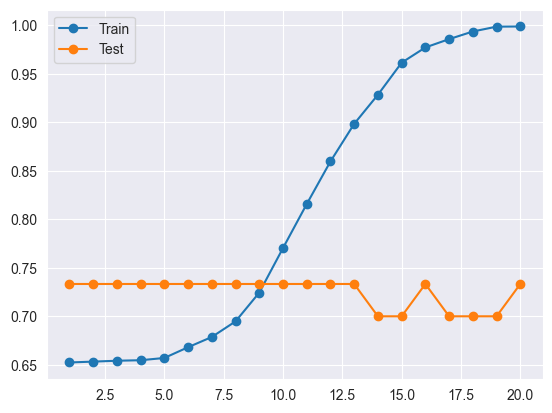

In [62]:
# define lists to collect scores
train_scores, test_scores = list(), list()

# define the tree depths to evaluate
values = [i for i in range(1, 21)]

# evaluate a decision tree for each depth
for i in values:
	# configure the model
	model = RandomForestClassifier(
		n_estimators = 100,
		max_depth = i
		)
	# fit model on the training dataset
	model.fit(x_train, y_train)
	
	# evaluate on the train dataset
	y_pred = model.predict(x_train)
	train_acc = accuracy_score(y_train, y_pred)
	train_scores.append(train_acc)
	
	# evaluate on the test dataset
	y_pred = model.predict(x_test)
	test_acc = accuracy_score(y_test, y_pred)
	test_scores.append(test_acc)
	
    # summarize progress
	print('>%d, train: %.3f, test: %.3f' % (i, train_acc, test_acc))
# plot of train and test scores vs tree depth
plt.plot(values, train_scores, '-o', label='Train')
plt.plot(values, test_scores, '-o', label='Test')
plt.legend()
plt.show()

## Random Forest com shift

In [63]:
df_forest_shift = df.copy()
df_forest_shift['shift1'] = df_forest_shift['var'].shift()

for i in [7, 2, 14, 30]:
    df_forest_shift[f'shift{i}'] = df_forest_shift[f'var'].shift(i)

df_forest_shift.tail(10)

,var,alta,shift1,shift7,shift2,shift14,shift30
data,,,,,,,
2025-06-21,0.00,False,-1.15,0.00,0.00,0.00,-0.44
2025-06-22,0.00,False,0.00,0.00,-1.15,0.00,0.40
2025-06-23,-0.41,False,0.00,1.49,0.00,-0.30,0.00
2025-06-24,0.45,True,-0.41,-0.30,0.00,0.54,0.00
2025-06-25,-1.02,False,0.45,-0.09,-0.41,0.51,0.23
2025-06-26,0.99,True,-1.02,0.00,0.45,0.49,1.02
2025-06-27,-0.18,False,0.99,-1.15,-1.02,-0.43,-0.47
2025-06-28,0.00,False,-0.18,0.00,0.99,0.00,-0.25
2025-06-29,0.00,False,0.00,0.00,-0.18,0.00,-1.09


In [64]:
prediction_n = 30

y_train = df_forest_shift.iloc[:-prediction_n]['alta']
y_test = df_forest_shift.iloc[-prediction_n:]['alta']

columns = ['shift1','shift7','shift2','shift14','shift30']

x_train = df_forest_shift.iloc[:-prediction_n][columns]
x_test = df_forest_shift.iloc[-prediction_n:][columns]

print(f'Train\t{len(y_train)}\nTest\t{len(y_test)}')

Train	5602
Test	30


>1	 train: 0.652 | test: 0.733
>2	 train: 0.652 | test: 0.733
>3	 train: 0.664 | test: 0.733
>4	 train: 0.687 | test: 0.733
>5	 train: 0.723 | test: 0.800
>6	 train: 0.763 | test: 0.733
>7	 train: 0.807 | test: 0.733
>8	 train: 0.853 | test: 0.833
>9	 train: 0.890 | test: 0.800
>10	 train: 0.909 | test: 0.733
>11	 train: 0.933 | test: 0.767
>12	 train: 0.948 | test: 0.733
>13	 train: 0.956 | test: 0.800
>14	 train: 0.966 | test: 0.700
>15	 train: 0.978 | test: 0.733
>16	 train: 0.981 | test: 0.733
>17	 train: 0.986 | test: 0.667
>18	 train: 0.989 | test: 0.733
>19	 train: 0.991 | test: 0.733
>20	 train: 0.994 | test: 0.700


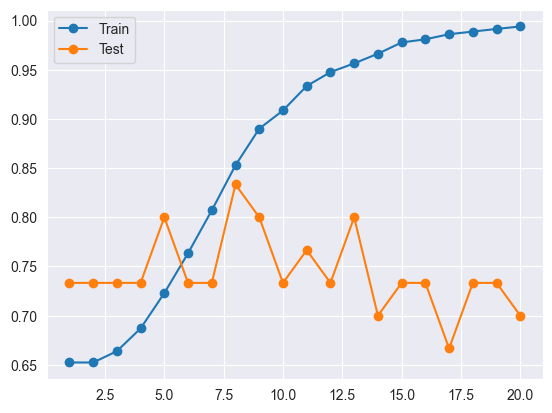

In [65]:
# define lists to collect scores
train_scores, test_scores = list(), list()

# define the tree depths to evaluate
values = [i for i in range(1, 21)]

# evaluate a decision tree for each depth
for i in values:
	# configure the model
	model = RandomForestClassifier(
		n_estimators = 100,
		max_depth = i,
		random_state=SEED
		)
	# fit model on the training dataset
	model.fit(x_train, y_train)
	
	# evaluate on the train dataset
	y_pred = model.predict(x_train)
	train_acc = accuracy_score(y_train, y_pred)
	train_scores.append(train_acc)
	
	# evaluate on the test dataset
	y_pred = model.predict(x_test)
	test_acc = accuracy_score(y_test, y_pred)
	test_scores.append(test_acc)
	
    # summarize progress
	print('>%d\t train: %.3f | test: %.3f' % (i, train_acc, test_acc))
# plot of train and test scores vs tree depth
plt.plot(values, train_scores, '-o', label='Train')
plt.plot(values, test_scores, '-o', label='Test')
plt.legend()
plt.show()

In [66]:
current_model = 'rfc(100, 8) - ma'
model = RandomForestClassifier(
		n_estimators = 100,
		max_depth = 8,
		random_state=SEED
		)
y_pred = model.fit(x_train, y_train).predict(x_test)

model_predictions[current_model] = [model, y_pred]

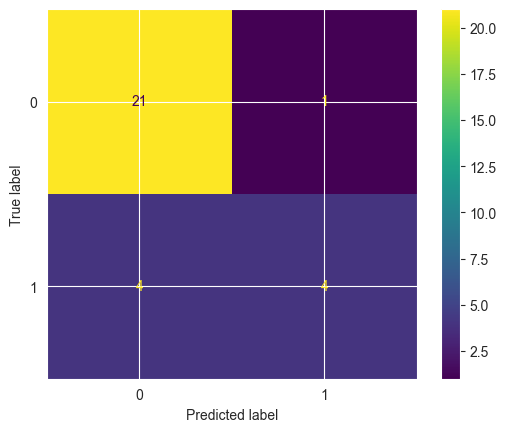

In [67]:
cm = confusion_matrix(
    y_true = y_test,
    y_pred = y_pred)

ConfusionMatrixDisplay(
    cm
).plot()

## Random Forest com shift

## Random Forest com shift booleano

## Logistic Regresstion with lag

### import

In [68]:
from sklearn.linear_model import LogisticRegression

### Training

In [69]:
df_lr = df.copy()

df_lr = df_lr.drop(filled_days)

In [70]:
lags = [x for x in range(1,15)]
lag_columns = []

for i in lags:
    df_lr[f'shift{i}'] = df_lr['var'].shift(i)
    lag_columns += [f'shift{i}']

df_lr = df_lr[lags[-1]:]
df_lr

,var,alta,shift1,shift2,shift3,shift4,shift5,shift6,shift7,shift8,shift9,shift10,shift11,shift12,shift13,shift14
data,,,,,,,,,,,,,,,,
2010-02-22,-0.61,False,-0.35,0.82,2.17,-0.41,1.66,0.51,2.48,0.62,-1.83,-4.73,-0.08,0.89,1.79,-0.28
2010-02-23,-1.60,False,-0.61,-0.35,0.82,2.17,-0.41,1.66,0.51,2.48,0.62,-1.83,-4.73,-0.08,0.89,1.79
2010-02-24,-0.47,False,-1.60,-0.61,-0.35,0.82,2.17,-0.41,1.66,0.51,2.48,0.62,-1.83,-4.73,-0.08,0.89
2010-02-25,0.50,True,-0.47,-1.60,-0.61,-0.35,0.82,2.17,-0.41,1.66,0.51,2.48,0.62,-1.83,-4.73,-0.08
2010-02-26,0.58,True,0.50,-0.47,-1.60,-0.61,-0.35,0.82,2.17,-0.41,1.66,0.51,2.48,0.62,-1.83,-4.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-24,0.45,True,-0.41,-1.15,-0.09,-0.30,1.49,-0.43,0.49,0.51,0.54,-0.30,-0.10,-0.56,-0.40,0.56
2025-06-25,-1.02,False,0.45,-0.41,-1.15,-0.09,-0.30,1.49,-0.43,0.49,0.51,0.54,-0.30,-0.10,-0.56,-0.40
2025-06-26,0.99,True,-1.02,0.45,-0.41,-1.15,-0.09,-0.30,1.49,-0.43,0.49,0.51,0.54,-0.30,-0.10,-0.56


In [71]:
prediction_n = 30

y_train = df_lr.iloc[:-prediction_n]['alta']
y_test = df_lr.iloc[-prediction_n:]['alta']

columns = lag_columns

x_train = df_lr.iloc[:-prediction_n][columns]
x_test = df_lr.iloc[-prediction_n:][columns]

print(f'Train\t{len(y_train)}\nTest\t{len(y_test)}')

Train	3777
Test	30


In [72]:
current_model = 'logistic_regression1 - shift'

model = LogisticRegression(
    random_state = SEED
)
y_pred = model.fit(x_train, y_train).predict(x_test)

0.5666666666666667


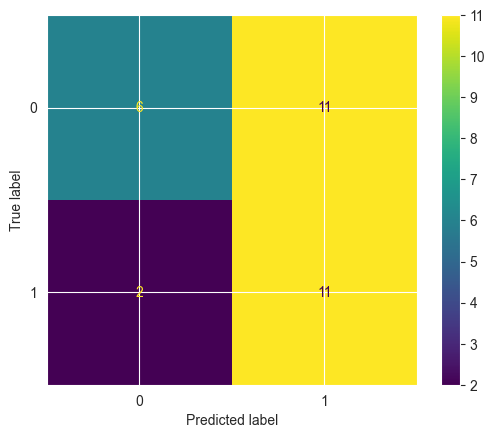

In [73]:
print(accuracy_score(y_test, y_pred))
cm = confusion_matrix(
    y_true = y_test,
    y_pred = y_pred)

ConfusionMatrixDisplay(
    cm
).plot()

## Logistic Regression com MA

In [74]:
df_lr = df.copy()

df_lr = df_lr.drop(filled_days)

ma = [5, 10, 15]
lag_columns = []

for i in ma:
    df_lr[f'roll{i}'] = df_lr['var'].rolling(i).mean()
    lag_columns += [f'roll{i}']

df_lr = df_lr[ma[-1]:]
df_lr

,var,alta,roll5,roll10,roll15
data,,,,,
2010-02-23,-1.60,False,0.086,0.529,0.088667
2010-02-24,-0.47,False,-0.442,0.420,-0.062000
2010-02-25,0.50,True,-0.506,0.222,-0.088000
2010-02-26,0.58,True,-0.320,0.229,-0.044000
2010-03-01,1.09,True,0.020,0.172,0.344000
...,...,...,...,...,...
2025-06-24,0.45,True,-0.300,0.110,0.020000
2025-06-25,-1.02,False,-0.444,-0.046,-0.085333
2025-06-26,0.99,True,-0.228,0.002,0.007333


In [75]:
prediction_n = 30

y_train = df_lr.iloc[:-prediction_n]['alta']
y_test = df_lr.iloc[-prediction_n:]['alta']

columns = lag_columns

x_train = df_lr.iloc[:-prediction_n][columns]
x_test = df_lr.iloc[-prediction_n:][columns]

print(f'Train\t{len(y_train)}\nTest\t{len(y_test)}')

current_model = 'logistic_regression2 - ma'

model = LogisticRegression(
    random_state = SEED
)
y_pred = model.fit(x_train, y_train).predict(x_test)

Train	3776
Test	30


0.6


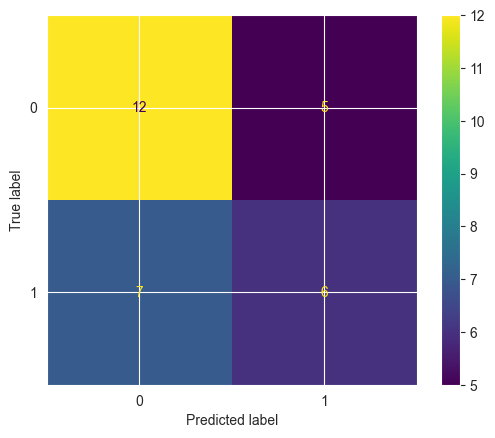

In [76]:
print(accuracy_score(y_test, y_pred))
cm = confusion_matrix(
    y_true = y_test,
    y_pred = y_pred)

ConfusionMatrixDisplay(
    cm
).plot()

### Slicing train data

In [77]:
def get_indexes_by_date_range(
        df : pd.DataFrame, 
        start = '0000-01-01', 
        end = '9999-12-12'):
    mask = (df.index > start) & (df.index < end)
    return mask

def slice_by_mask(df, mask):
    sliced = df.loc[mask]
    return sliced

def slice_by_date_range(
    df : pd.DataFrame, 
    start = '0000-01-01', 
    end = '9999-12-12'    
):
    mask = get_indexes_by_date_range(df, start, end)
    sliced = slice_by_mask(df, mask)
    return sliced

In [78]:
df_lr_slice = slice_by_date_range(df_lr, '2021-01-01')

In [79]:
prediction_n = 30

y_train = df_lr_slice.iloc[:-prediction_n]['alta']
y_test = df_lr_slice.iloc[-prediction_n:]['alta']

columns = lag_columns

x_train = df_lr_slice.iloc[:-prediction_n][columns]
x_test = df_lr_slice.iloc[-prediction_n:][columns]

print(f'Train\t{len(y_train)}\nTest\t{len(y_test)}')

current_model = 'logistic_regression2 - ma'

model = LogisticRegression(
    random_state = SEED
)
y_pred = model.fit(x_train, y_train).predict(x_test)

Train	1088
Test	30


0.5333333333333333


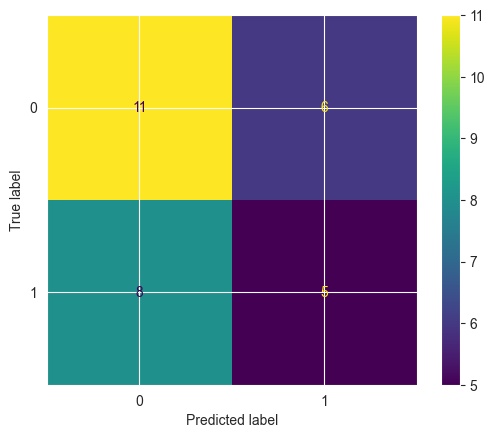

In [80]:
print(accuracy_score(y_test, y_pred))
cm = confusion_matrix(
    y_true = y_test,
    y_pred = y_pred)

ConfusionMatrixDisplay(
    cm
).plot()

## Logistic Regression with lag and MA

In [81]:
df_lr_lag_ma = df.copy()

df_lr_lag_ma = df_lr_lag_ma.drop(filled_days)

ma = [5, 10, 15]
train_columns = []

for i in ma:
    df_lr_lag_ma[f'roll{i}'] = df_lr_lag_ma['var'].rolling(i).mean()
    train_columns += [f'roll{i}']

df_lr_lag_ma['shift1'] = df_lr_lag_ma['var'].shift(1)


train_columns += ['shift1']

df_lr_lag_ma = df_lr_lag_ma[ma[-1]:]
df_lr_lag_ma

,var,alta,roll5,roll10,roll15,shift1
data,,,,,,
2010-02-23,-1.60,False,0.086,0.529,0.088667,-0.61
2010-02-24,-0.47,False,-0.442,0.420,-0.062000,-1.60
2010-02-25,0.50,True,-0.506,0.222,-0.088000,-0.47
2010-02-26,0.58,True,-0.320,0.229,-0.044000,0.50
2010-03-01,1.09,True,0.020,0.172,0.344000,0.58
...,...,...,...,...,...,...
2025-06-24,0.45,True,-0.300,0.110,0.020000,-0.41
2025-06-25,-1.02,False,-0.444,-0.046,-0.085333,0.45
2025-06-26,0.99,True,-0.228,0.002,0.007333,-1.02


In [82]:
prediction_n = 30

y_train = df_lr_lag_ma.iloc[:-prediction_n]['alta']
y_test = df_lr_lag_ma.iloc[-prediction_n:]['alta']

columns = lag_columns

x_train = df_lr_lag_ma.iloc[:-prediction_n][columns]
x_test = df_lr_lag_ma.iloc[-prediction_n:][columns]

print(f'Train\t{len(y_train)}\nTest\t{len(y_test)}')

current_model = 'logistic_regression2 - ma'

model = LogisticRegression(
    random_state = SEED
)
y_pred = model.fit(x_train, y_train).predict(x_test)

x_train.head()

Train	3776
Test	30


,roll5,roll10,roll15
data,,,
2010-02-23,0.086,0.529,0.088667
2010-02-24,-0.442,0.420,-0.062000
2010-02-25,-0.506,0.222,-0.088000
2010-02-26,-0.320,0.229,-0.044000
2010-03-01,0.020,0.172,0.344000


In [94]:
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, roc_auc_score
def matrix_and_score(y_test, y_pred, model_name = ''):
    print(f'TESTS ON MODEL {model_name} =========================')
    print(f'Accuracy\t{accuracy_score(y_test, y_pred)}\n')
    print(f'Precision\t{precision_score(y_test, y_pred)}\n- Accuracy on positives\n')
    print(f'Recall\t\t{recall_score(y_test, y_pred)}\n- Accuracy on negatives\n')
    print(f'ROC AUC\t{roc_auc_score(y_test, y_pred)}')
    

    cm = confusion_matrix(
        y_true = y_test,
        y_pred = y_pred)

    ConfusionMatrixDisplay(
        cm
    ).plot()

TESTS ON MODEL  =========================
Accuracy	0.6

Precision	0.5454545454545454
- Accuracy on positives

Recall		0.46153846153846156
- Accuracy on negatives

ROC AUC	0.583710407239819


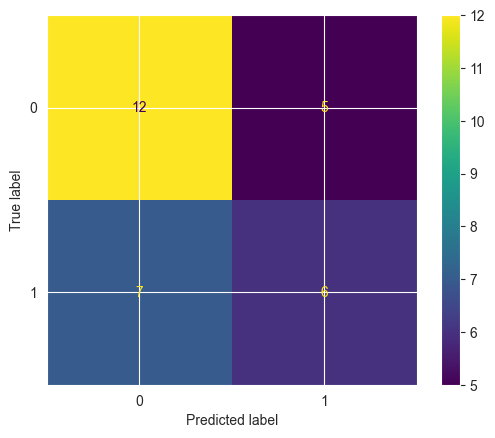

In [96]:
matrix_and_score(y_test, y_pred)

In [97]:
[x for x in range(1, 10, 5)]

[1, 6]

In [98]:
df.iloc[-5:]

,var,alta
data,,
2025-06-26,0.99,True
2025-06-27,-0.18,False
2025-06-28,0.00,False
2025-06-29,0.00,False
2025-06-30,1.45,True


In [ ]:
def lr_grid(
        base_df,
        target_col : str = 'alta',
        prediction_n = 30,
        lag_start : int = 1,
        lag_end : int = 31,
        lag_step : int = 1,
        print_progress = False
        ):
    lags = [i for i in range(lag_start, lag_end, lag_step)]
    
    new_df = base_df.copy()

    acc_scores = []

    for i in lags:
        new_col = f'lag{i}'
        new_df[new_col] = new_df[target_col].shift(i)

        new_df = new_df.iloc[i:]

        y_test = new_df.iloc[-prediction_n:][target_col]
        y_train = new_df.iloc[:-prediction_n][target_col]

        x_test = new_df.iloc[-prediction_n:][[new_col]]
        x_train = new_df.iloc[:-prediction_n][[new_col]]

        model = LogisticRegression(
            random_state = SEED
        )

        if print_progress: 
            print(f'Train\t{len(y_train)}\nTest\t{len(y_test)}')

        y_pred = pd.DataFrame(model.fit(x_train, y_train).predict(x_test))

        if print_progress:
            print(f'LR (lag{i})\t{accuracy_score(y_test, y_pred)} | len: {len(y_pred)}')

        acc_scores += [[f'LAG {i}', accuracy_score(y_test, y_pred), [y_pred]]]

    return acc_scores

    

In [ ]:
def lr_grid(
        base_df,
        target_col : str = 'alta',
        prediction_n = 30,
        lag_start : int = 1,
        lag_end : int = 31,
        lag_step : int = 1,
        print_progress = False
        ):
    lags = [i for i in range(lag_start, lag_end, lag_step)]
    
    new_df = base_df.copy()

    acc_scores = []

    for i in lags:
        new_col = f'lag{i}'
        new_df[new_col] = new_df[target_col].shift(i)

        new_df = new_df.iloc[i:]

        y_test = new_df.iloc[-prediction_n:][target_col]
        y_train = new_df.iloc[:-prediction_n][target_col]

        x_test = new_df.iloc[-prediction_n:][[new_col]]
        x_train = new_df.iloc[:-prediction_n][[new_col]]

        model = LogisticRegression(
            random_state = SEED
        )

        if print_progress: 
            print(f'Train\t{len(y_train)}\nTest\t{len(y_test)}')

        y_pred = pd.DataFrame(model.fit(x_train, y_train).predict(x_test))

        if print_progress:
            print(f'LR (lag{i})\t{accuracy_score(y_test, y_pred)} | len: {len(y_pred)}')

        acc_scores += [[f'LAG {i}', accuracy_score(y_test, y_pred), [y_pred]]]

    return acc_scores

    

TESTS ON MODEL  =========================
Accuracy	0.6285714285714286

Precision	0.0
- Accuracy on positives

Recall		0.0
- Accuracy on negatives

ROC AUC	0.5


d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


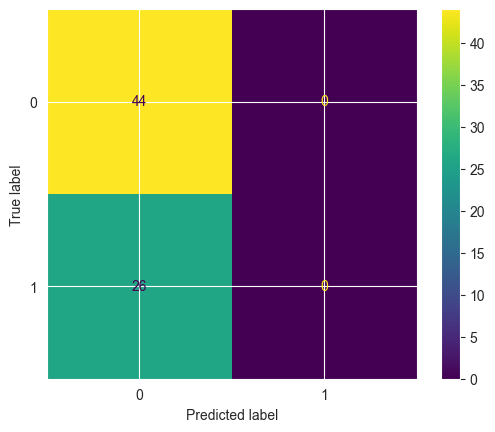

In [199]:
prediction_n = 70
new_df = df.copy()
print_progress = True
acc_scores = []
target_col = 'alta'

i = 10

new_col = f'lag{i}'
new_df[new_col] = new_df[target_col].shift(i)

new_df = new_df.iloc[i:]

y_test = new_df.iloc[-prediction_n:][target_col]
y_train = new_df.iloc[:-prediction_n][target_col]

x_test = new_df.iloc[-prediction_n:][[new_col]]
x_train = new_df.iloc[:-prediction_n][[new_col]]

model = LogisticRegression(
    random_state = SEED
)

# if print_progress: 
#     print(f'Train\t{len(y_train)}\nTest\t{len(y_test)}')

y_pred = model.fit(x_train, y_train).predict(x_test)
# if print_progress:
#     print(f'LR (lag{i})\t{accuracy_score(y_test, y_pred)} | len: {len(y_pred)}')

# acc_scores += [[f'LAG {i}', accuracy_score(y_test, y_pred), [y_pred]]]
matrix_and_score(y_test, y_pred)

In [190]:
lr_grid_results = lr_grid(
    base_df = df,
    print_progress = True
)

lr_grid_results.sort(key = lambda x : x[1])

first = lr_grid_results[0]

# y_test
y_pred = first[2]


Train	5601
Test	30
LR (lag1)	0.7333333333333333 | len: 30
Train	5599
Test	30
LR (lag2)	0.7333333333333333 | len: 30
Train	5596
Test	30
LR (lag3)	0.7333333333333333 | len: 30
Train	5592
Test	30
LR (lag4)	0.7333333333333333 | len: 30
Train	5587
Test	30
LR (lag5)	0.7333333333333333 | len: 30
Train	5581
Test	30
LR (lag6)	0.7333333333333333 | len: 30
Train	5574
Test	30
LR (lag7)	0.7333333333333333 | len: 30
Train	5566
Test	30
LR (lag8)	0.7333333333333333 | len: 30
Train	5557
Test	30
LR (lag9)	0.7333333333333333 | len: 30
Train	5547
Test	30
LR (lag10)	0.7333333333333333 | len: 30
Train	5536
Test	30
LR (lag11)	0.7333333333333333 | len: 30
Train	5524
Test	30
LR (lag12)	0.7333333333333333 | len: 30
Train	5511
Test	30
LR (lag13)	0.7333333333333333 | len: 30
Train	5497
Test	30
LR (lag14)	0.7333333333333333 | len: 30
Train	5482
Test	30
LR (lag15)	0.7333333333333333 | len: 30
Train	5466
Test	30
LR (lag16)	0.7333333333333333 | len: 30
Train	5449
Test	30
LR (lag17)	0.7333333333333333 | len: 30
Train	

In [191]:
print(lr_grid_results)

[['LAG 1', 0.7333333333333333, [        0
0   False
1   False
2   False
3   False
4   False
5   False
6   False
7   False
8   False
9   False
10  False
11  False
12  False
13  False
14  False
15  False
16  False
17  False
18  False
19  False
20  False
21  False
22  False
23  False
24  False
25  False
26  False
27  False
28  False
29  False]], ['LAG 2', 0.7333333333333333, [        0
0   False
1   False
2   False
3   False
4   False
5   False
6   False
7   False
8   False
9   False
10  False
11  False
12  False
13  False
14  False
15  False
16  False
17  False
18  False
19  False
20  False
21  False
22  False
23  False
24  False
25  False
26  False
27  False
28  False
29  False]], ['LAG 3', 0.7333333333333333, [        0
0   False
1   False
2   False
3   False
4   False
5   False
6   False
7   False
8   False
9   False
10  False
11  False
12  False
13  False
14  False
15  False
16  False
17  False
18  False
19  False
20  False
21  False
22  False
23  False
24  False
25  False
26  False


## KNN

***
# 5.